In [3]:
pip install mysql-connector-python==8.0.33

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.6 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 3.8 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 3.2 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 3.2 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 3.2 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\LAYBA ALI\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [4]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="poilkjmnb03.la",
    database="ecommerce",
    auth_plugin='mysql_native_password'   
)

print("Connected!")

Connected!


In [6]:
import pandas as pd

query = """
SELECT delivery_status, COUNT(*) AS orders
FROM (
    SELECT
        order_id,
        CASE
            WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 'Delayed'
            ELSE 'On Time'
        END AS delivery_status
    FROM orders
    WHERE order_status = 'delivered'
) t
GROUP BY delivery_status;
"""

df = pd.read_sql(query, conn)
df

C:\Users\LAYBA ALI\AppData\Local\Temp\ipykernel_18400\2899104077.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,delivery_status,orders
0,On Time,88652
1,Delayed,7826


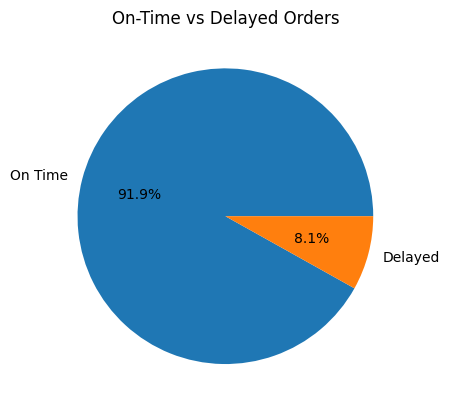

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.pie(df['orders'], labels=df['delivery_status'], autopct='%1.1f%%')
plt.title("On-Time vs Delayed Orders")
plt.savefig("C:/Users/LAYBA ALI/Downloads/ecommerce-sql-analysis/outputs/charts/delivery_performance.png")
plt.show()

In [11]:
query_weight = """
SELECT
    CASE
        WHEN p.product_weight_g < 500 THEN 'Light'
        WHEN p.product_weight_g < 2000 THEN 'Medium'
        ELSE 'Heavy'
    END AS weight_category,

    ROUND(
        AVG(
            DATEDIFF(
                o.order_delivered_customer_date,
                o.order_purchase_timestamp
            )
        ),
        2
    ) AS avg_delivery_days

FROM order_items oi

JOIN products p
    ON oi.product_id = p.product_id

JOIN orders o
    ON oi.order_id = o.order_id

WHERE o.order_status = 'delivered'
  AND p.product_weight_g IS NOT NULL

GROUP BY weight_category

ORDER BY
    CASE weight_category
        WHEN 'Light' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'Heavy' THEN 3
    END;
"""

df_weight = pd.read_sql(query_weight, conn)

df_weight

C:\Users\LAYBA ALI\AppData\Local\Temp\ipykernel_18400\1959841369.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_weight = pd.read_sql(query_weight, conn)


,weight_category,avg_delivery_days
0,Light,11.69
1,Medium,12.46
2,Heavy,13.58


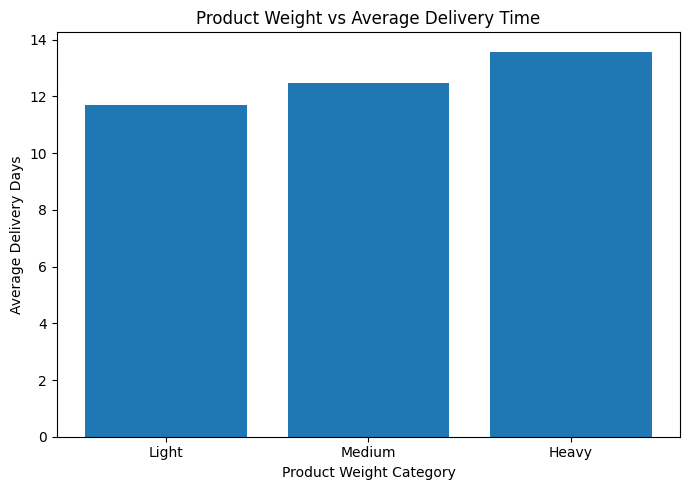

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(df_weight["weight_category"],df_weight["avg_delivery_days"])

plt.title("Product Weight vs Average Delivery Time")
plt.xlabel("Product Weight Category")
plt.ylabel("Average Delivery Days")

plt.tight_layout()
plt.savefig("C:/Users/LAYBA ALI/Downloads/ecommerce-sql-analysis/outputs/charts/weight_vs_delivery_time.png",dpi=300,bbox_inches="tight")
plt.show()
plt.close()

In [14]:
query_seller_delivery = """
WITH order_sellers AS (

    SELECT
        order_id,
        COUNT(DISTINCT seller_id) AS seller_count
    FROM order_items
    GROUP BY order_id

),

delivery_base AS (

    SELECT
        order_id,

        CASE
            WHEN order_delivered_customer_date > order_estimated_delivery_date
                THEN 'Delayed'
            ELSE 'On Time'
        END AS delivery_status

    FROM orders
    WHERE order_status = 'delivered'

)

SELECT

    CASE
        WHEN os.seller_count = 1
            THEN 'Single Seller'
        ELSE 'Multi Seller'
    END AS order_type,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN db.delivery_status = 'Delayed'
                    THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS delayed_percentage

FROM order_sellers os

JOIN delivery_base db
    ON os.order_id = db.order_id

GROUP BY order_type;
"""

df_seller_delivery = pd.read_sql(
    query_seller_delivery,
    conn
)

df_seller_delivery

C:\Users\LAYBA ALI\AppData\Local\Temp\ipykernel_18400\3568641606.py:56: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_seller_delivery = pd.read_sql(


,order_type,delayed_percentage
0,Single Seller,8.20
1,Multi Seller,1.41


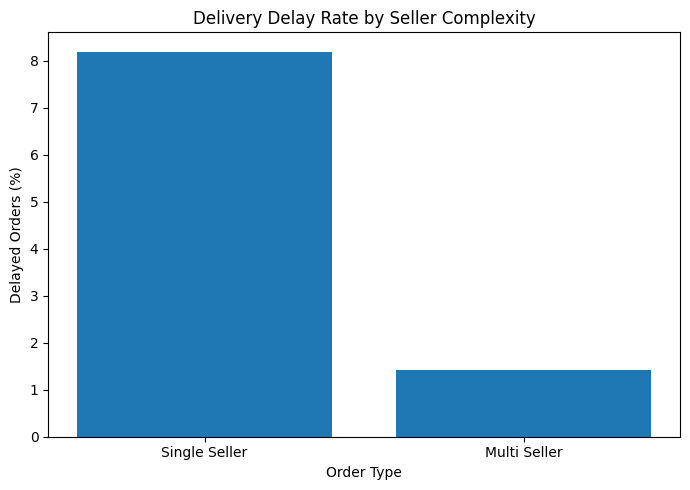

In [15]:
plt.figure(figsize=(7, 5))

plt.bar(df_seller_delivery["order_type"],df_seller_delivery["delayed_percentage"])

plt.title("Delivery Delay Rate by Seller Complexity")
plt.xlabel("Order Type")
plt.ylabel("Delayed Orders (%)")

plt.tight_layout()
plt.savefig("C:/Users/LAYBA ALI/Downloads/ecommerce-sql-analysis/outputs/charts/delay_rate_by_order_type.png",dpi=300,bbox_inches="tight")
plt.show()
plt.close()

In [16]:
query_revenue_delay = """
WITH delivery_base AS (

    SELECT

        order_id,

        CASE
            WHEN order_delivered_customer_date > order_estimated_delivery_date
                THEN 'Delayed'
            ELSE 'On Time'
        END AS delivery_status

    FROM orders

    WHERE order_status = 'delivered'
)

SELECT

    db.delivery_status,

    COUNT(*) AS orders,

    ROUND(
        AVG(p.total_payment),
        2
    ) AS avg_order_value,

    ROUND(
        SUM(p.total_payment),
        2
    ) AS total_revenue

FROM delivery_base db

JOIN payments_summary p
    ON db.order_id = p.order_id

GROUP BY db.delivery_status;
"""

df_revenue_delay = pd.read_sql(query_revenue_delay,conn)
df_revenue_delay

C:\Users\LAYBA ALI\AppData\Local\Temp\ipykernel_18400\2841934757.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue_delay = pd.read_sql(query_revenue_delay,conn)


,delivery_status,orders,avg_order_value,total_revenue
0,On Time,88652,158.72,14070814.98
1,Delayed,7825,172.73,1351646.79


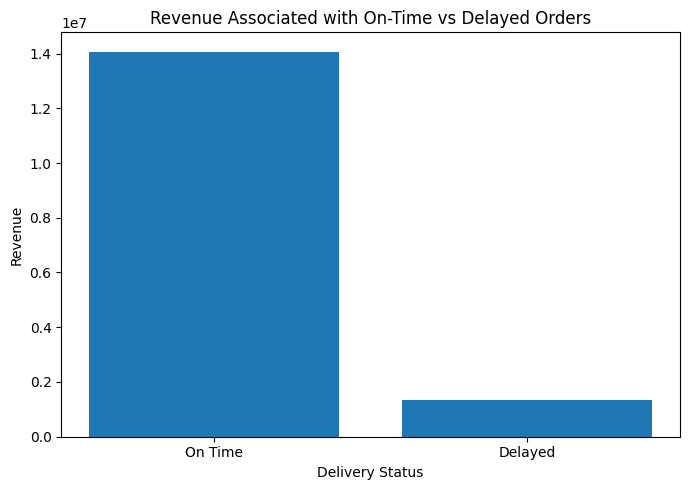

In [18]:
plt.figure(figsize=(7, 5))

plt.bar(df_revenue_delay["delivery_status"],df_revenue_delay["total_revenue"])

plt.title("Revenue Associated with On-Time vs Delayed Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("C:/Users/LAYBA ALI/Downloads/ecommerce-sql-analysis/outputs/charts/revenue_by_delivery_status.png",dpi=300,bbox_inches="tight")
plt.show()
plt.close()